In [20]:
import sklearn
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [21]:

# Load the dataset
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

# Scale the features
scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))

# Define X and y
y = coffee_data['target']
X = X_scaled_std.copy()

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_

# Use the stored column names to map the importances back to the feature names
important_features = sorted(zip(column_names, importances), key=lambda x: x[1], reverse=True)
feature_importance_dict = {feature: importance for feature, importance in zip(column_names, importances)}

# Display the most important features
for feature, importance in important_features:
    print(f"Feature: {feature}, Importance: {importance:.4f}")


Feature: clim_34_prec10_oct, Importance: 0.0726
Feature: env_75_geo_10, Importance: 0.0676
Feature: clim_14_tmax2_feb, Importance: 0.0625
Feature: clim_25_prec1_jan, Importance: 0.0538
Feature: clim_1_tmin1_jan, Importance: 0.0519
Feature: clim_40_temp_season, Importance: 0.0491
Feature: clim_27_prec3_mar, Importance: 0.0484
Feature: env_76_soi_10, Importance: 0.0457
Feature: clim_13_tmax1_jan, Importance: 0.0442
Feature: clim_26_prec2_feb, Importance: 0.0435
Feature: clim_35_prec11_nov, Importance: 0.0405
Feature: clim_38_mean_diurn_range, Importance: 0.0402
Feature: clim_39_isotherm, Importance: 0.0382
Feature: clim_28_prec4_apr, Importance: 0.0382
Feature: env_74_solrad, Importance: 0.0361
Feature: clim_69_cwd_annual, Importance: 0.0328
Feature: env_78_wat_2, Importance: 0.0322
Feature: env_73_asp, Importance: 0.0290
Feature: env_72_slo, Importance: 0.0270
Feature: env_79_forcov, Importance: 0.0191
Feature: env_76_soi_9, Importance: 0.0135
Feature: env_76_soi_21, Importance: 0.0132


In [22]:
importance_threshold = 0.001

# Identify features to remove
features_to_remove = [feature for feature, importance in feature_importance_dict.items() if importance < importance_threshold]

# Drop low-importance features from the dataset
#X_reduced = X.drop(columns=features_to_remove)
indices_to_remove = [list(column_names).index(feature) for feature in features_to_remove]

# Remove the low-importance features from the scaled NumPy array
X_reduced = np.delete(X, indices_to_remove, axis=1)

# Check the shape of the reduced feature matrix to ensure the columns have been removed
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
# Print out the features that are removed
print(f"Features removed: {features_to_remove}")

Original shape: (526, 78)
Reduced shape: (526, 46)
Features removed: ['env_75_geo_5', 'env_75_geo_11', 'env_76_soi_7', 'env_76_soi_23', 'env_76_soi_20', 'env_76_soi_19', 'env_76_soi_3', 'env_76_soi_15', 'env_76_soi_12', 'env_76_soi_22', 'env_76_soi_17', 'env_76_soi_8', 'env_76_soi_4', 'env_77_veg_1', 'env_77_veg_2', 'env_77_veg_3', 'env_77_veg_7', 'env_77_veg_9', 'env_77_veg_11', 'env_77_veg_12', 'env_77_veg_13', 'env_77_veg_22', 'env_78_wat_12', 'env_78_wat_11', 'env_78_wat_8', 'env_78_wat_20', 'env_78_wat_13', 'env_78_wat_22', 'env_78_wat_17', 'env_78_wat_1.1', 'env_78_wat_18', 'env_78_wat_15']


In [27]:
X_reduced_df = pd.DataFrame(X_reduced, columns=[col for col in column_names if col not in features_to_remove])
X_reduced_df['caffeine_class'] = coffee_data['caffeine_class']
X_reduced_df['caffeine_percent'] = coffee_data['caffeine_percent']
X_reduced_df.to_csv(r'../data/reduced_for_training.csv', index=False)


In [23]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define X and y (this assumes your data is already prepared as in your example)
X = X_reduced.copy()  # Your scaled data
y = coffee_data['target']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define the scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': make_scorer(roc_auc_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Perform cross-validation
cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)

# Print cross-validation results
print("Cross-validation results (mean values):")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall: {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score: {cv_results['test_f1'].mean():.4f}")


Cross-validation results (mean values):
Accuracy: 0.9348
ROC-AUC: 0.9087
Precision: 0.9200
Recall: 0.8514
F1-Score: 0.8810


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame (replace this with your actual data)
df = pd.read_csv(r"..\data\reduced_data.csv")
# df should have columns like 'soil_type' (categorical) and 'caffeine_content' (numerical)

# Check the first few rows of the DataFrame to ensure it's structured correctly
df = pd.concat([df, coffee_data["caffeine_percent"]], axis=1)

print(df.head())



   Unnamed: 0  env_71_alt  env_72_slo  env_73_asp  env_74_solrad  env_75_geo  \
0         0.0       477.0        11.0       346.0         7929.0         5.0   
1         1.0       261.0        13.0         7.0         8107.0        10.0   
2         2.0       253.0         1.0       247.0         7366.0        10.0   
3         3.0       253.0         1.0       247.0         7366.0        10.0   
4         4.0       253.0         1.0       247.0         7366.0        10.0   

   env_76_soi  env_77_veg  env_78_wat  env_79_forcov caffeine_class  \
0        15.0        12.0         6.0           68.0         Absent   
1         6.0        14.0         1.0           87.0            Low   
2        18.0         7.0         6.0            0.0         Absent   
3        18.0         7.0         6.0            0.0         Absent   
4        18.0         7.0         6.0            0.0         Absent   

   caffeine_percent  
0              0.00  
1              0.03  
2              0.00  
3   

In [30]:
coffee_data["caffeine_percent"]

0      0.00
1      0.03
2      0.00
3      0.00
4      0.00
       ... 
521    0.00
522    0.00
523    0.00
524    0.00
525    0.00
Name: caffeine_percent, Length: 526, dtype: float64

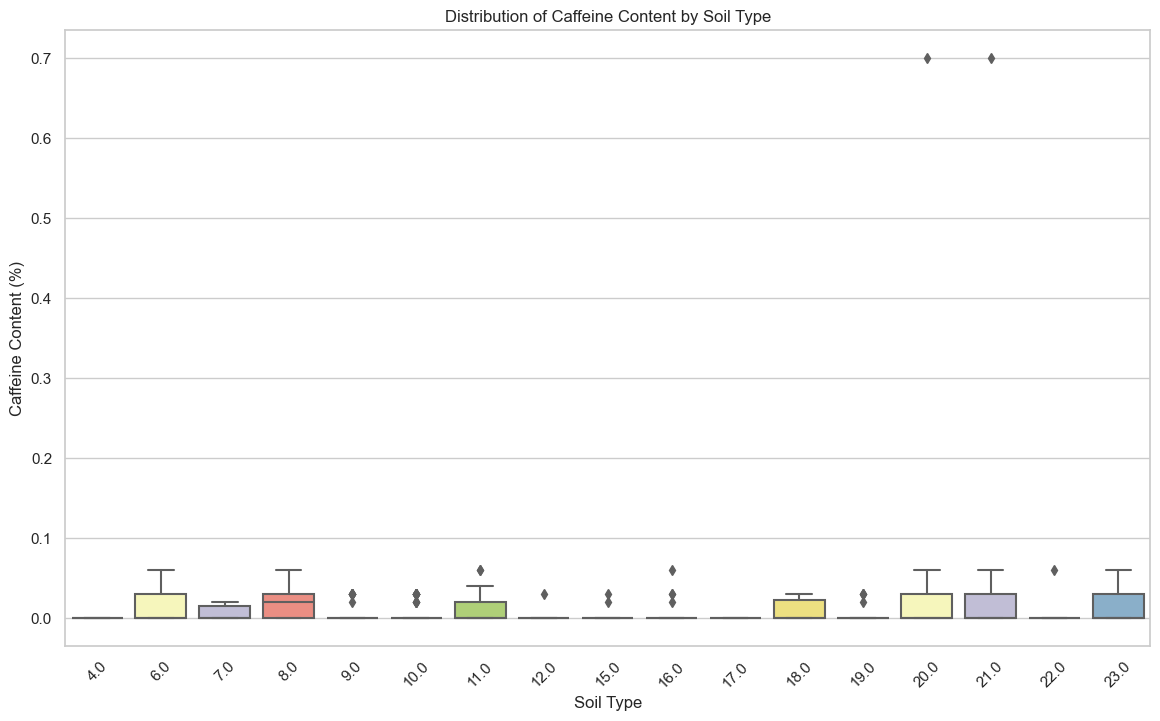

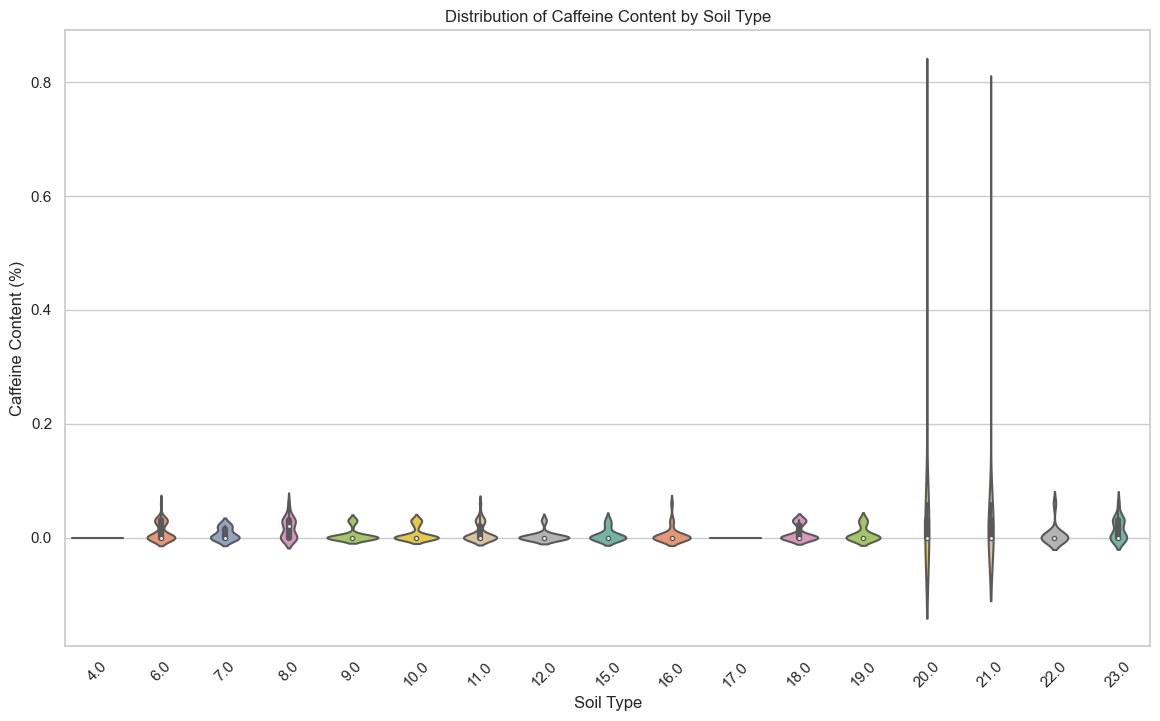

In [32]:
# Set the plot style
sns.set(style="whitegrid")

# Create a box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3')
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()

# Create a violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set2')
plt.title('Distribution of Caffeine Content by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better visibility
plt.show()

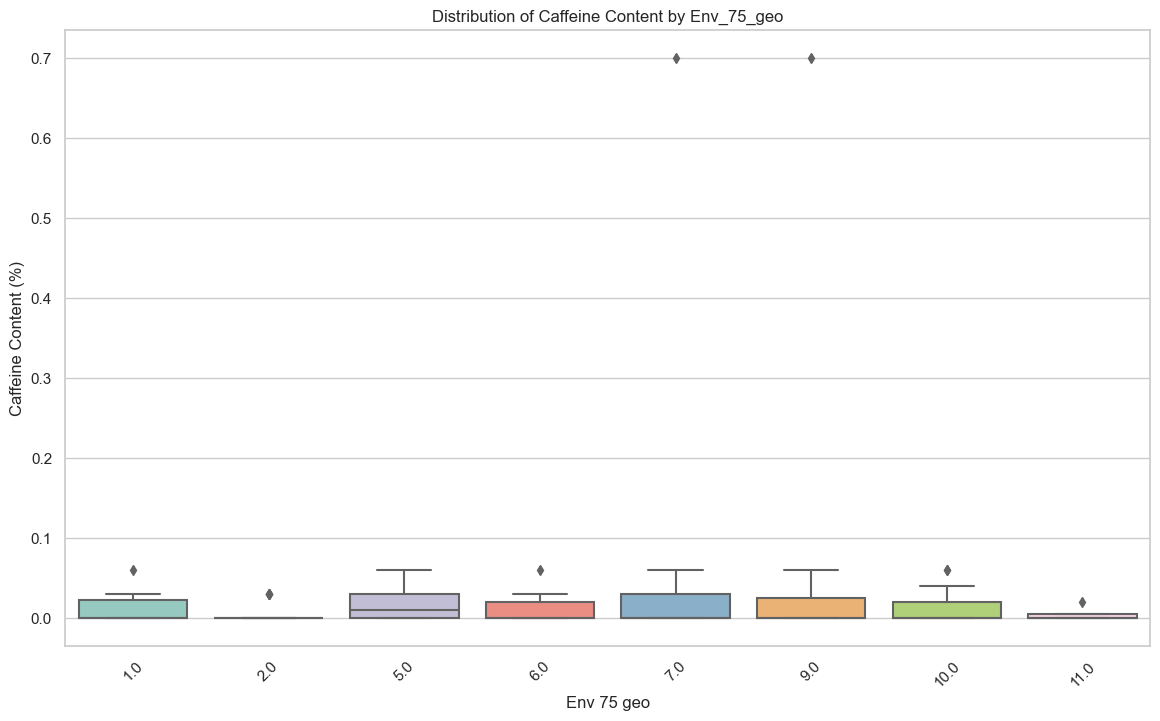

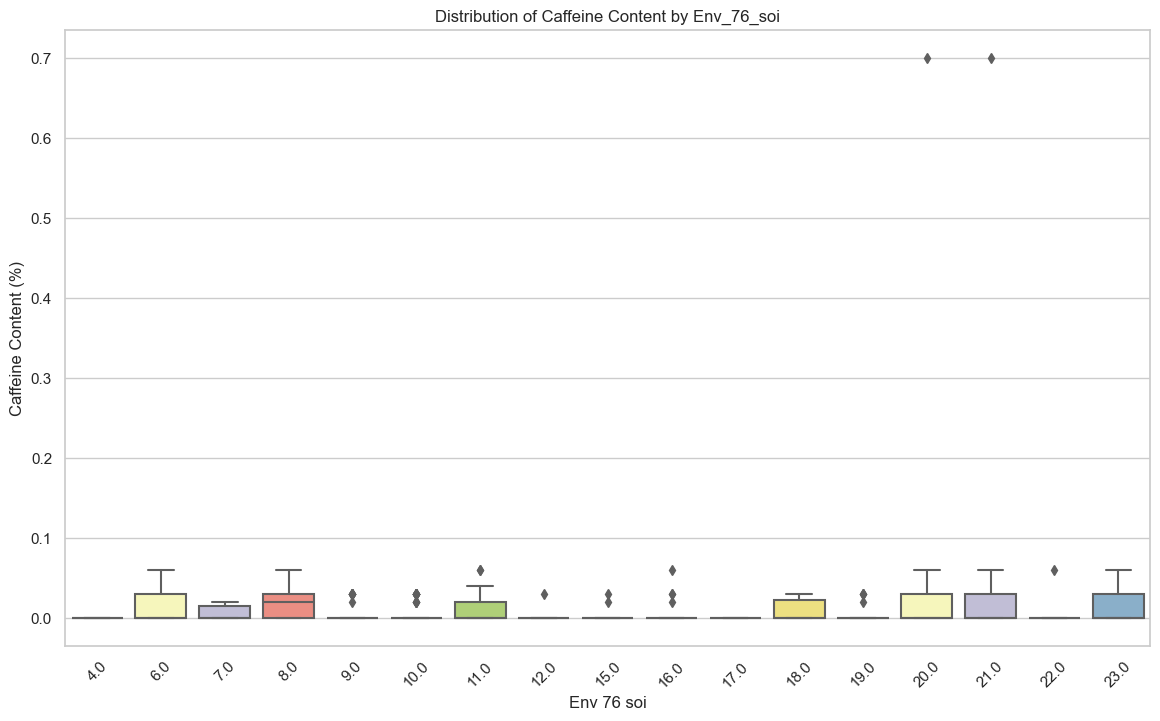

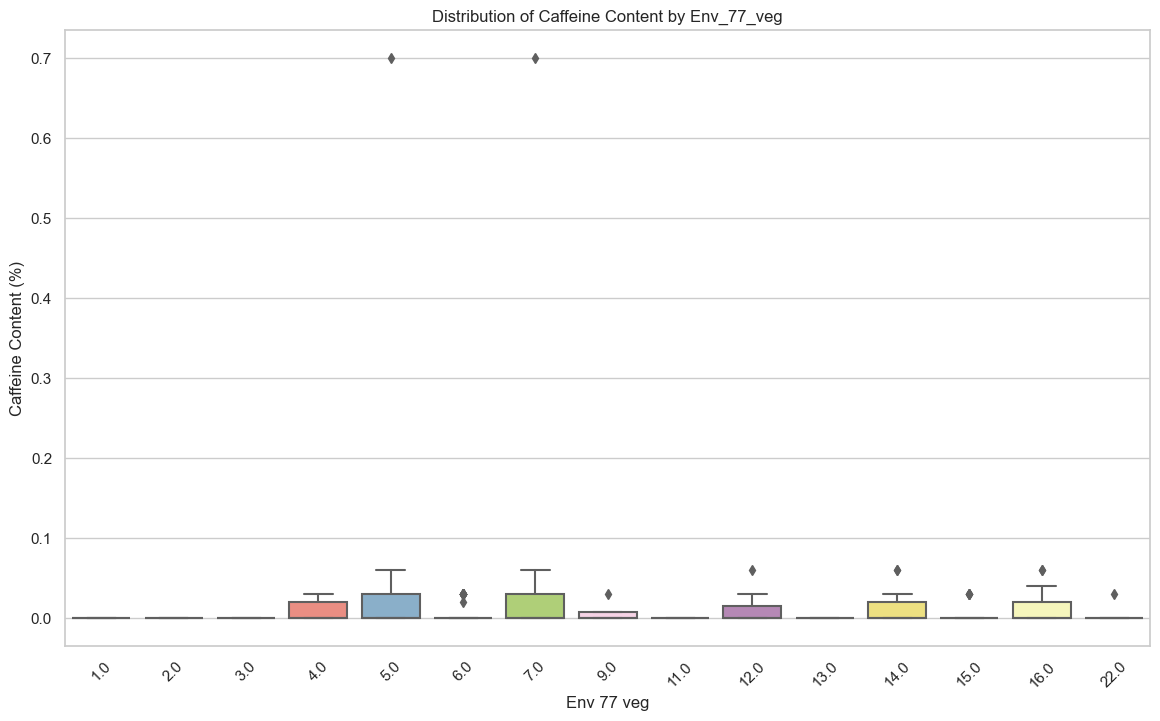

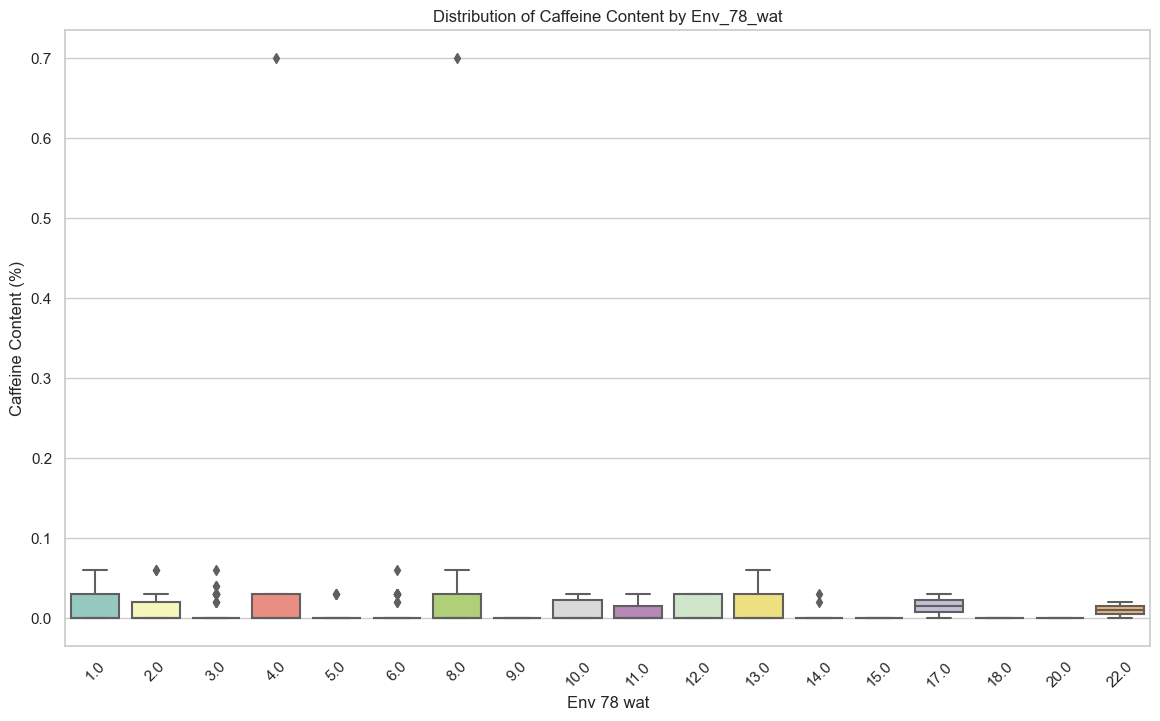

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# df = pd.read_csv('your_data.csv')

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat' ]

# Loop through each column and create a box plot or violin plot
for column in categorical_columns:
    plt.figure(figsize=(14, 8))
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3')  # You can use sns.violinplot() for violin plots
    plt.title(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xlabel(column.replace('_', ' ').capitalize())
    plt.ylabel('Caffeine Content (%)')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    plt.show()


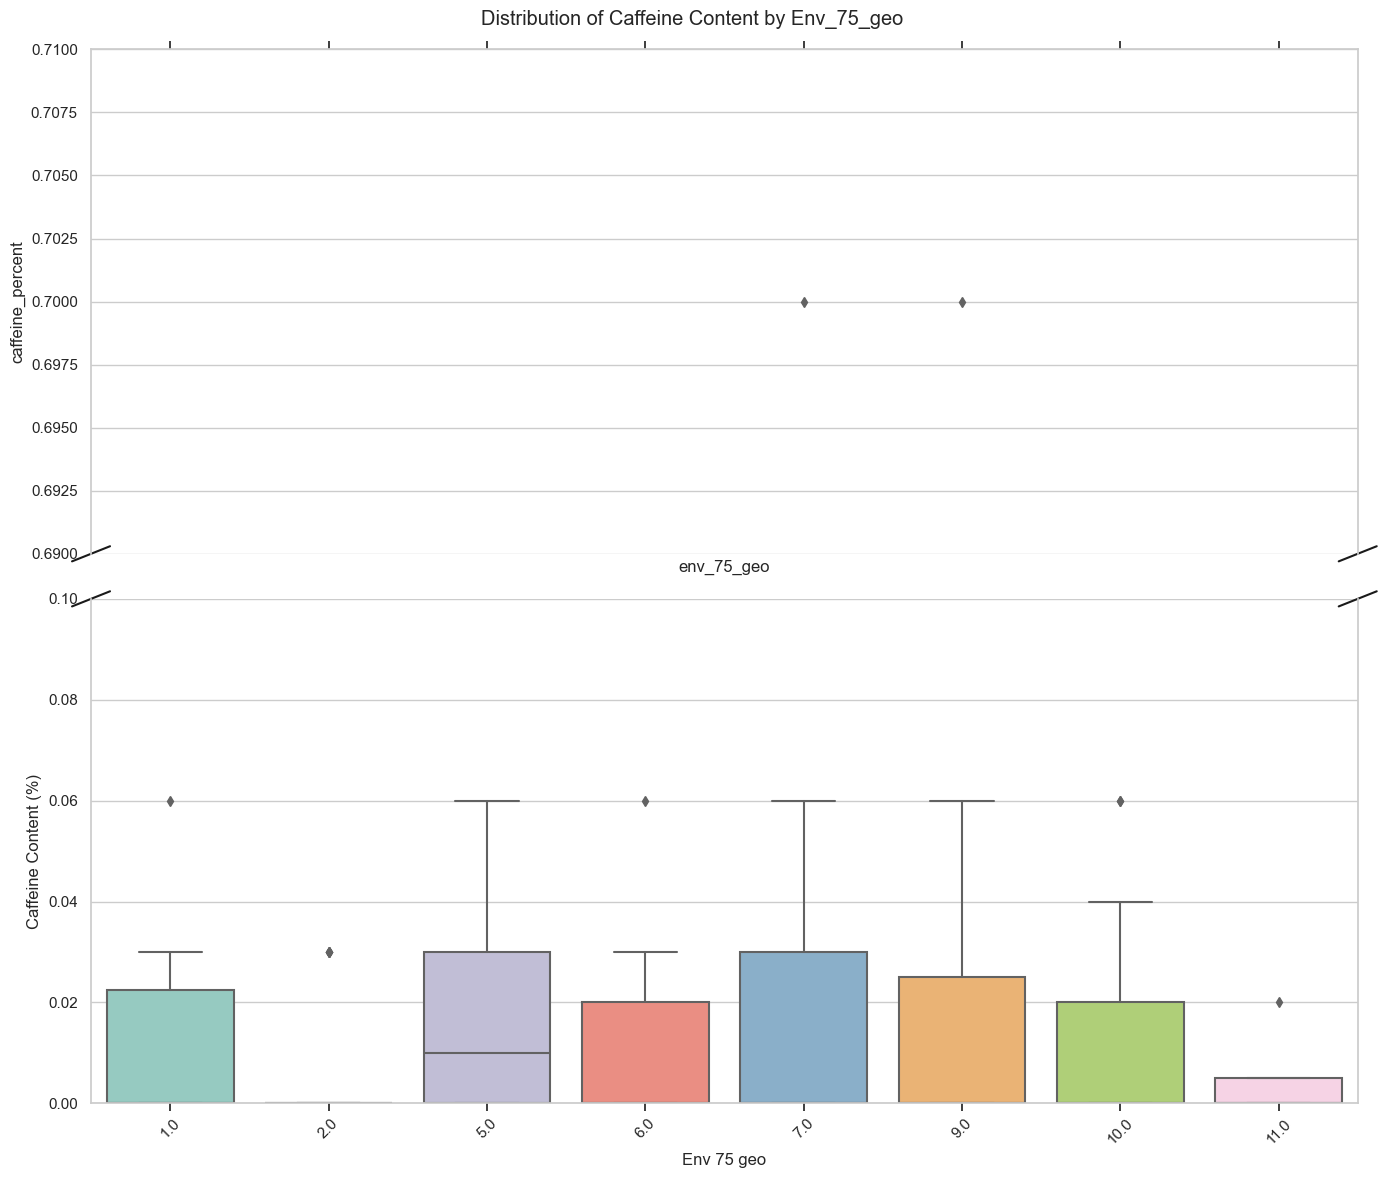

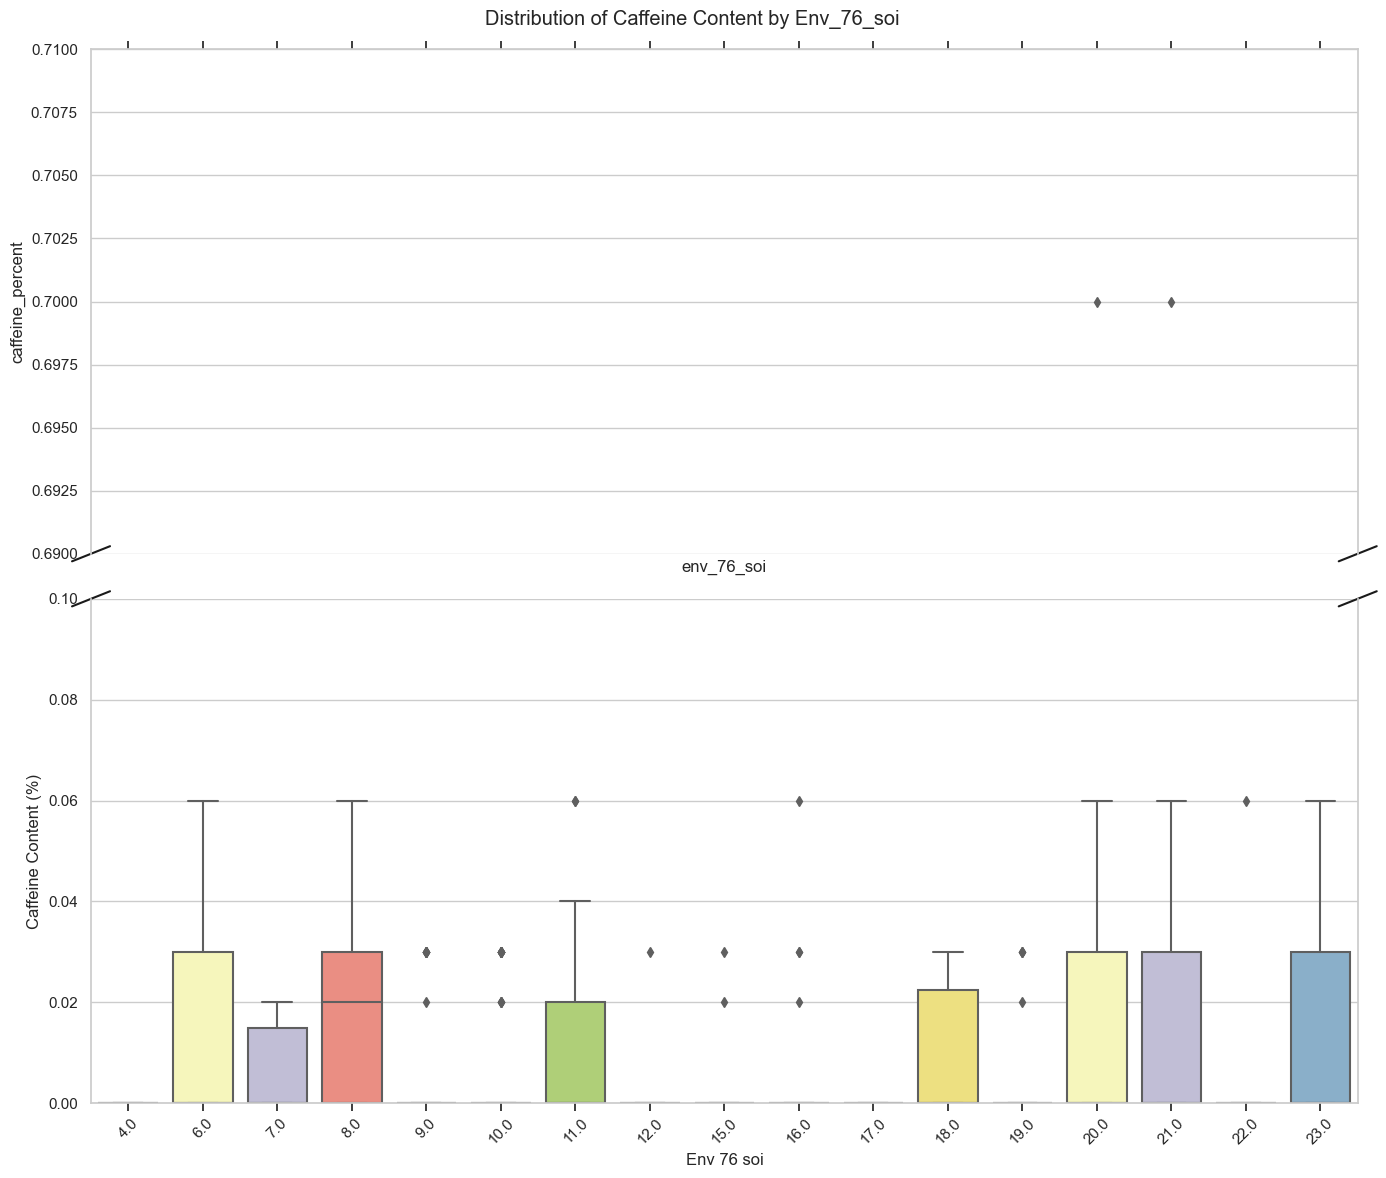

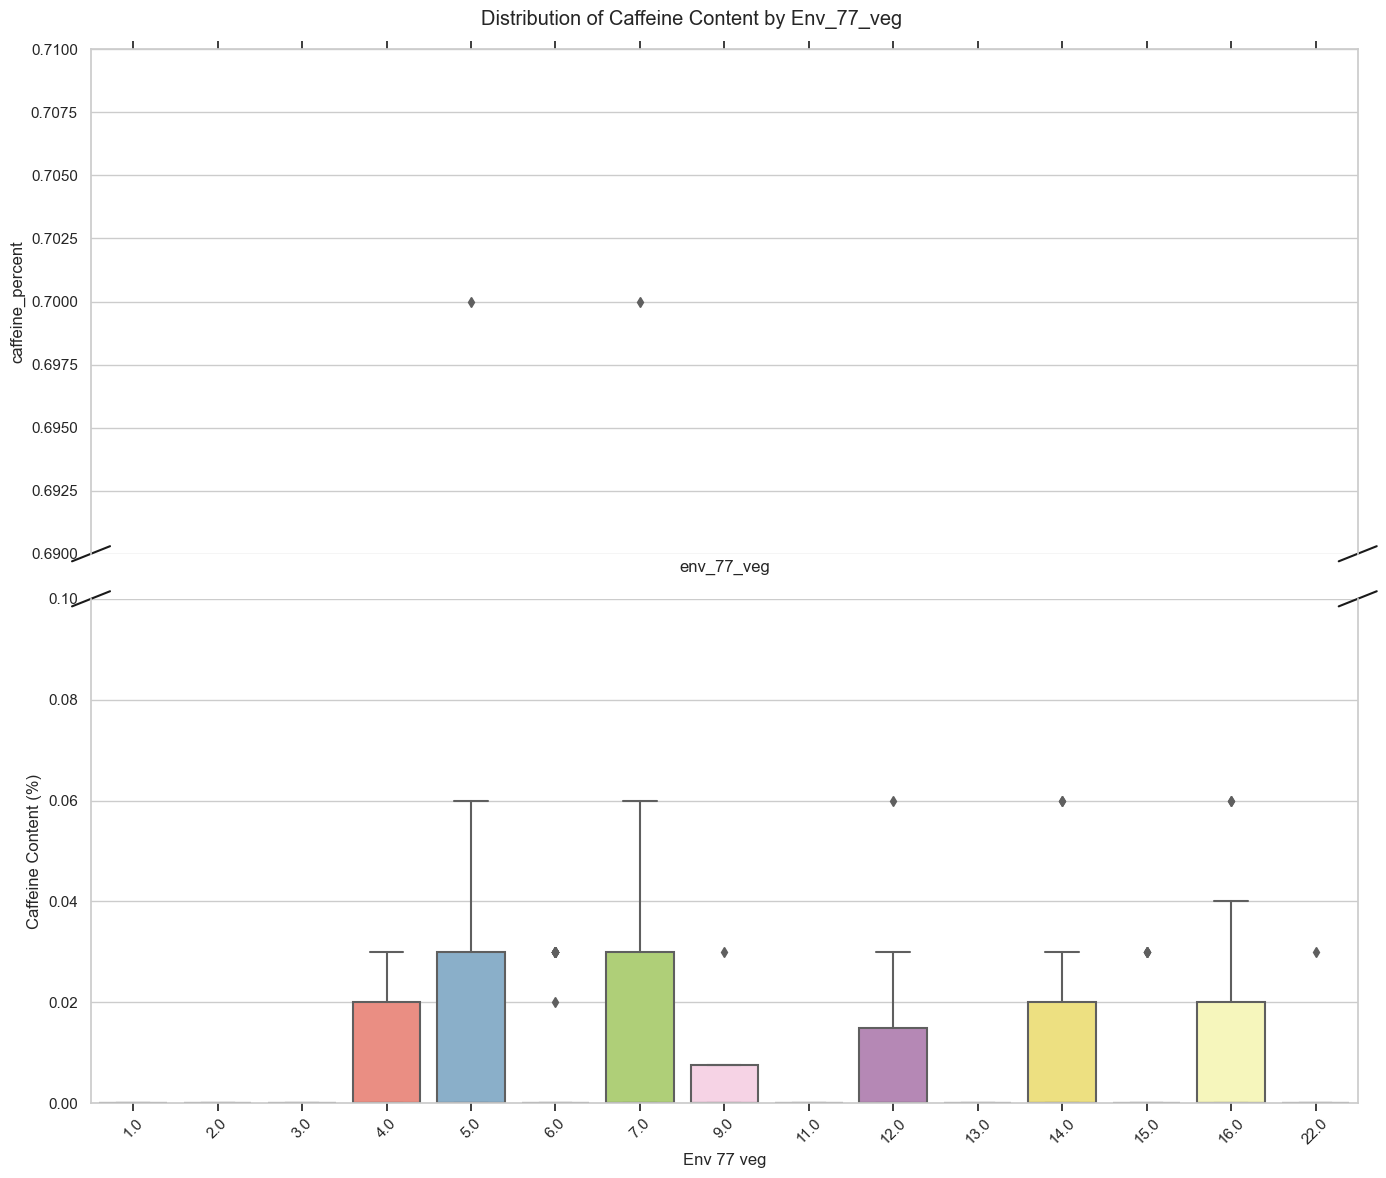

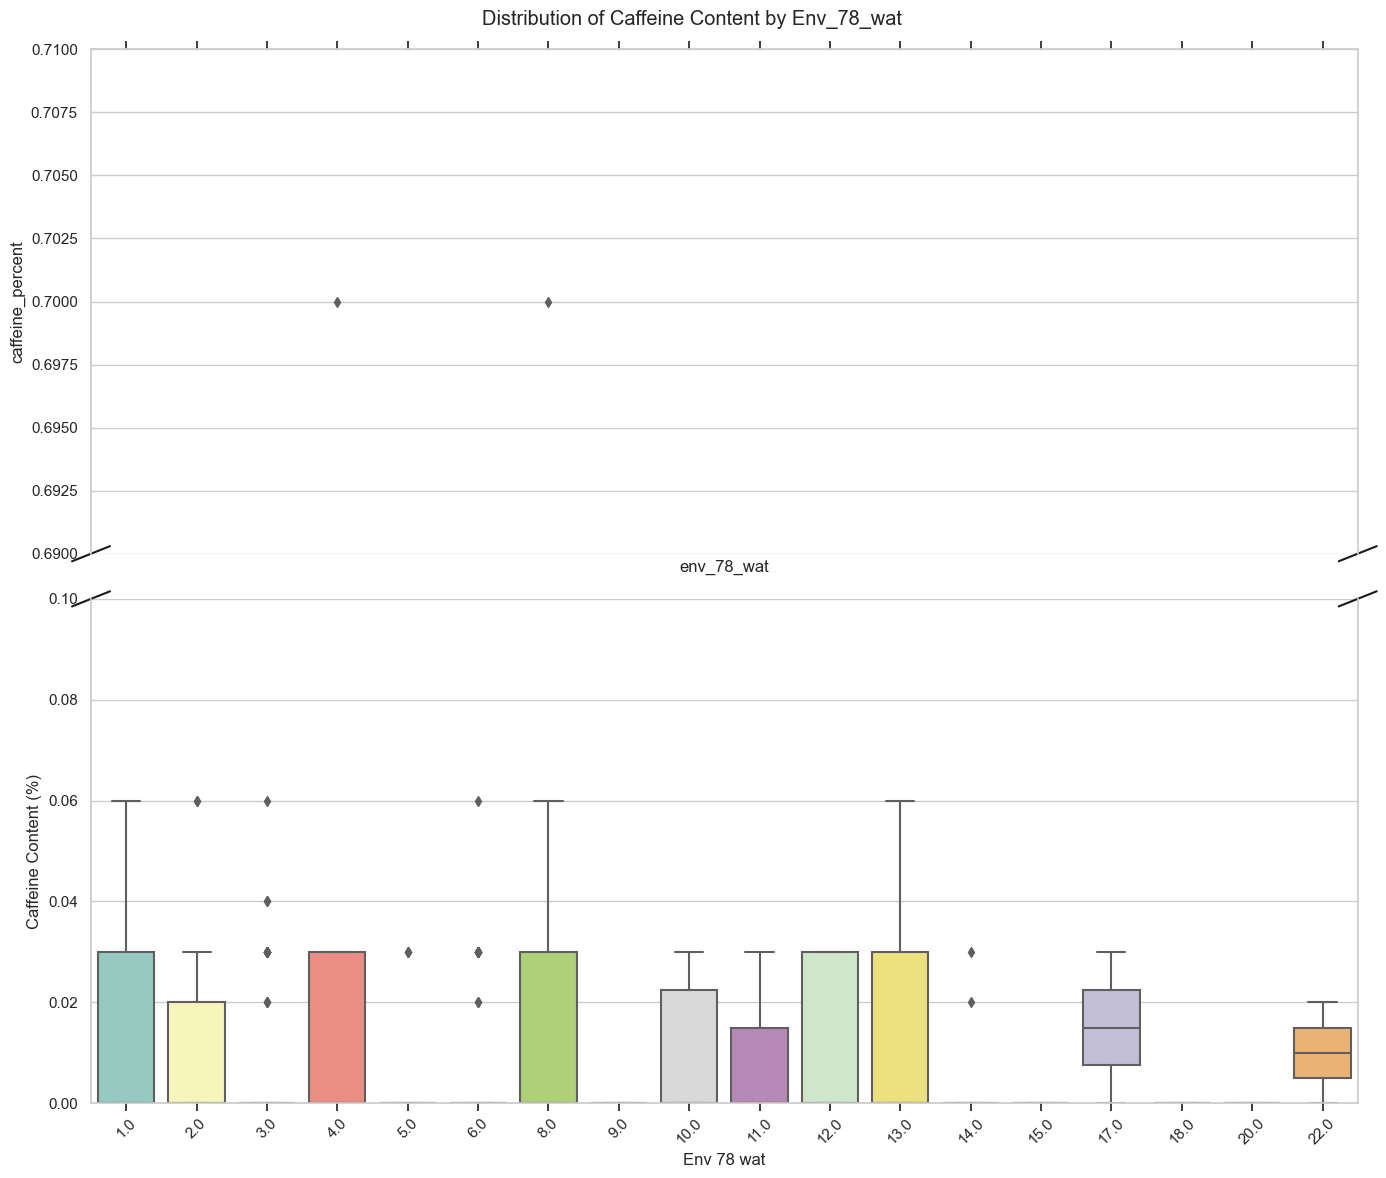

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Loop through each column and create a box plot with a broken y-axis
for column in categorical_columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 12) )#, gridspec_kw={'height_ratios': [1, 2]})
    
    # Top plot (above 0.65)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Adjust the upper limit as needed
    
    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Adjust the lower limit as needed

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    plt.suptitle(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    
    plt.tight_layout()
    plt.show()


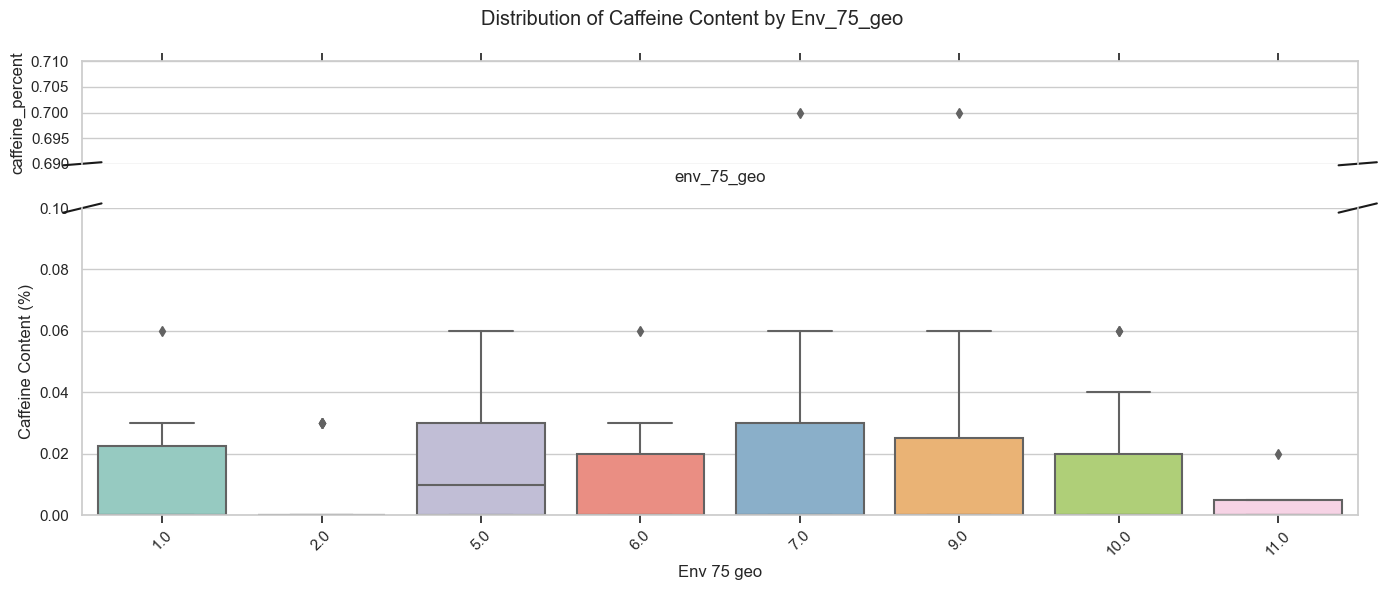

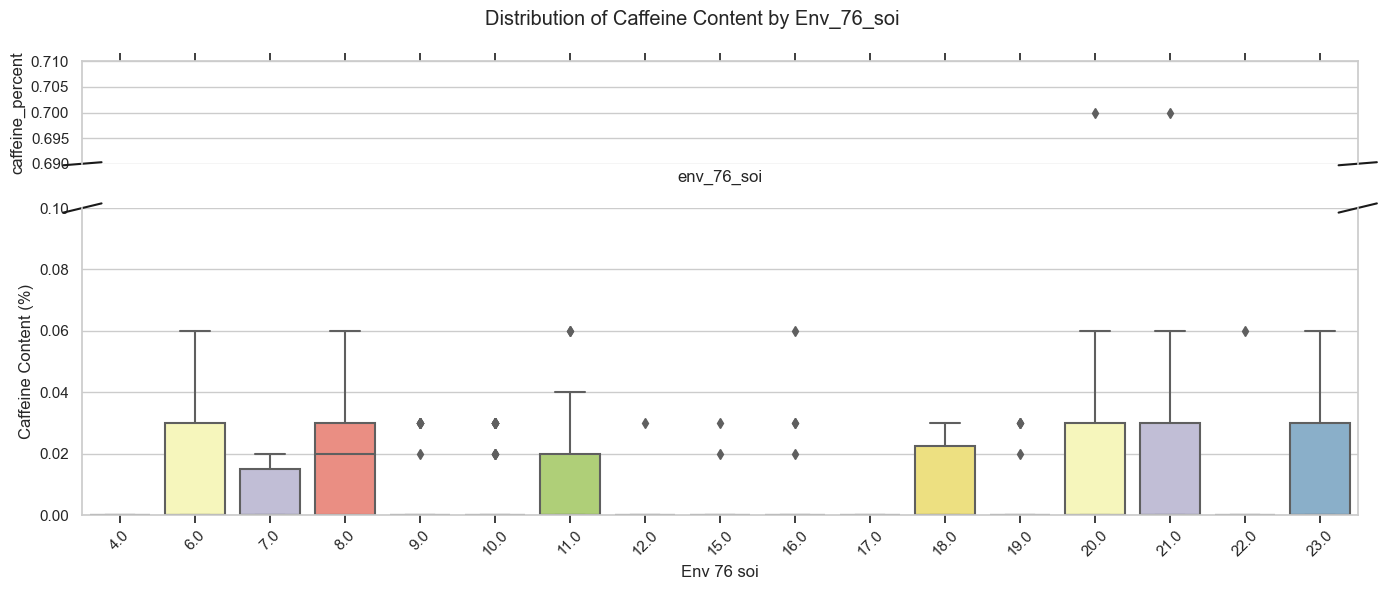

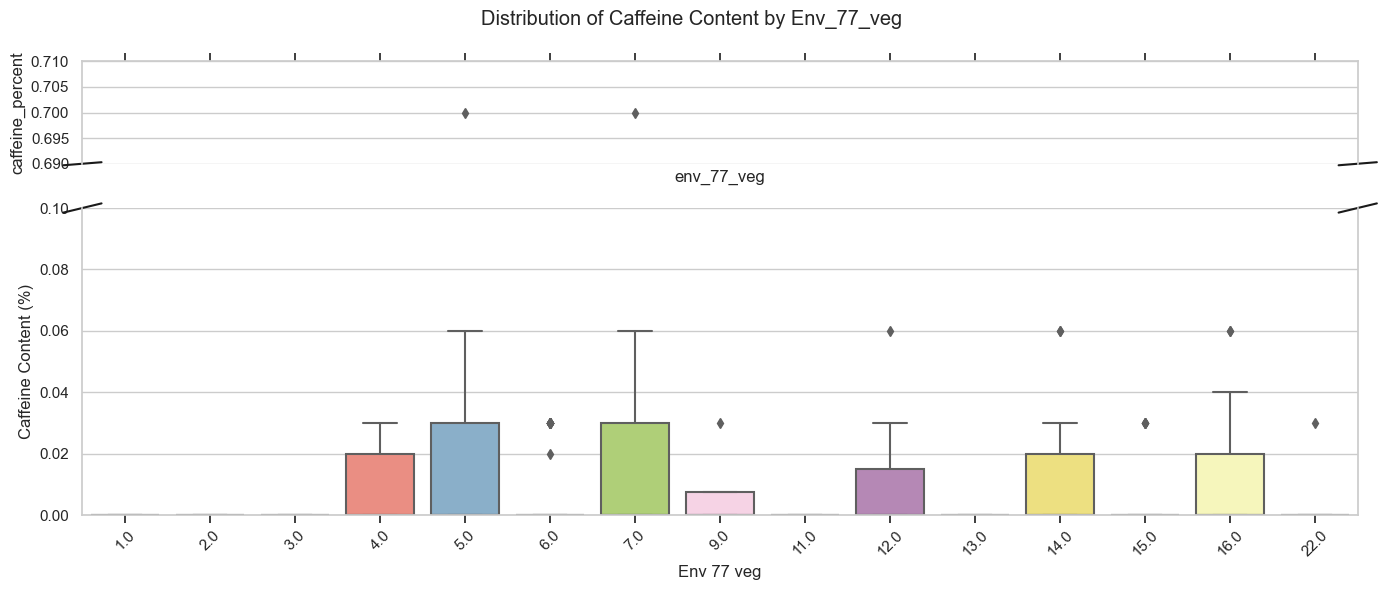

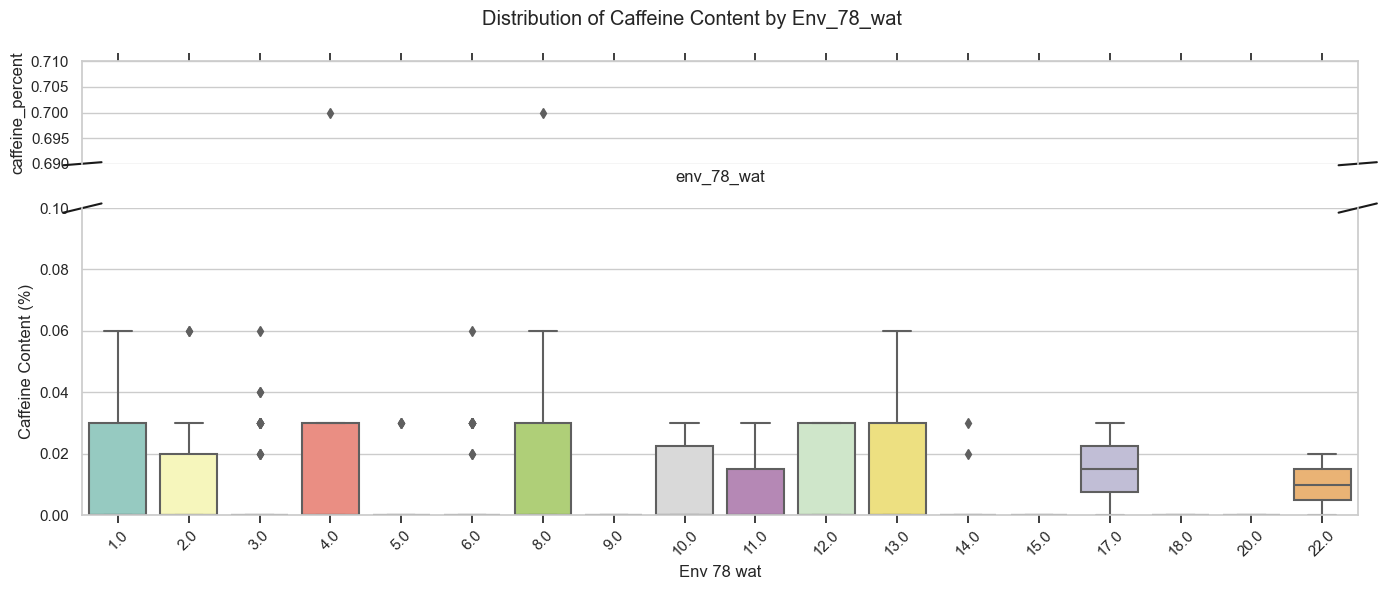

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Loop through each column and create a box plot with a broken y-axis
for column in categorical_columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 3]})
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
    ax1.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Emphasize the main range
    ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set the interval for the bottom part

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    plt.suptitle(f'Distribution of Caffeine Content by {column.capitalize()}')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    
    plt.tight_layout()
    plt.show()



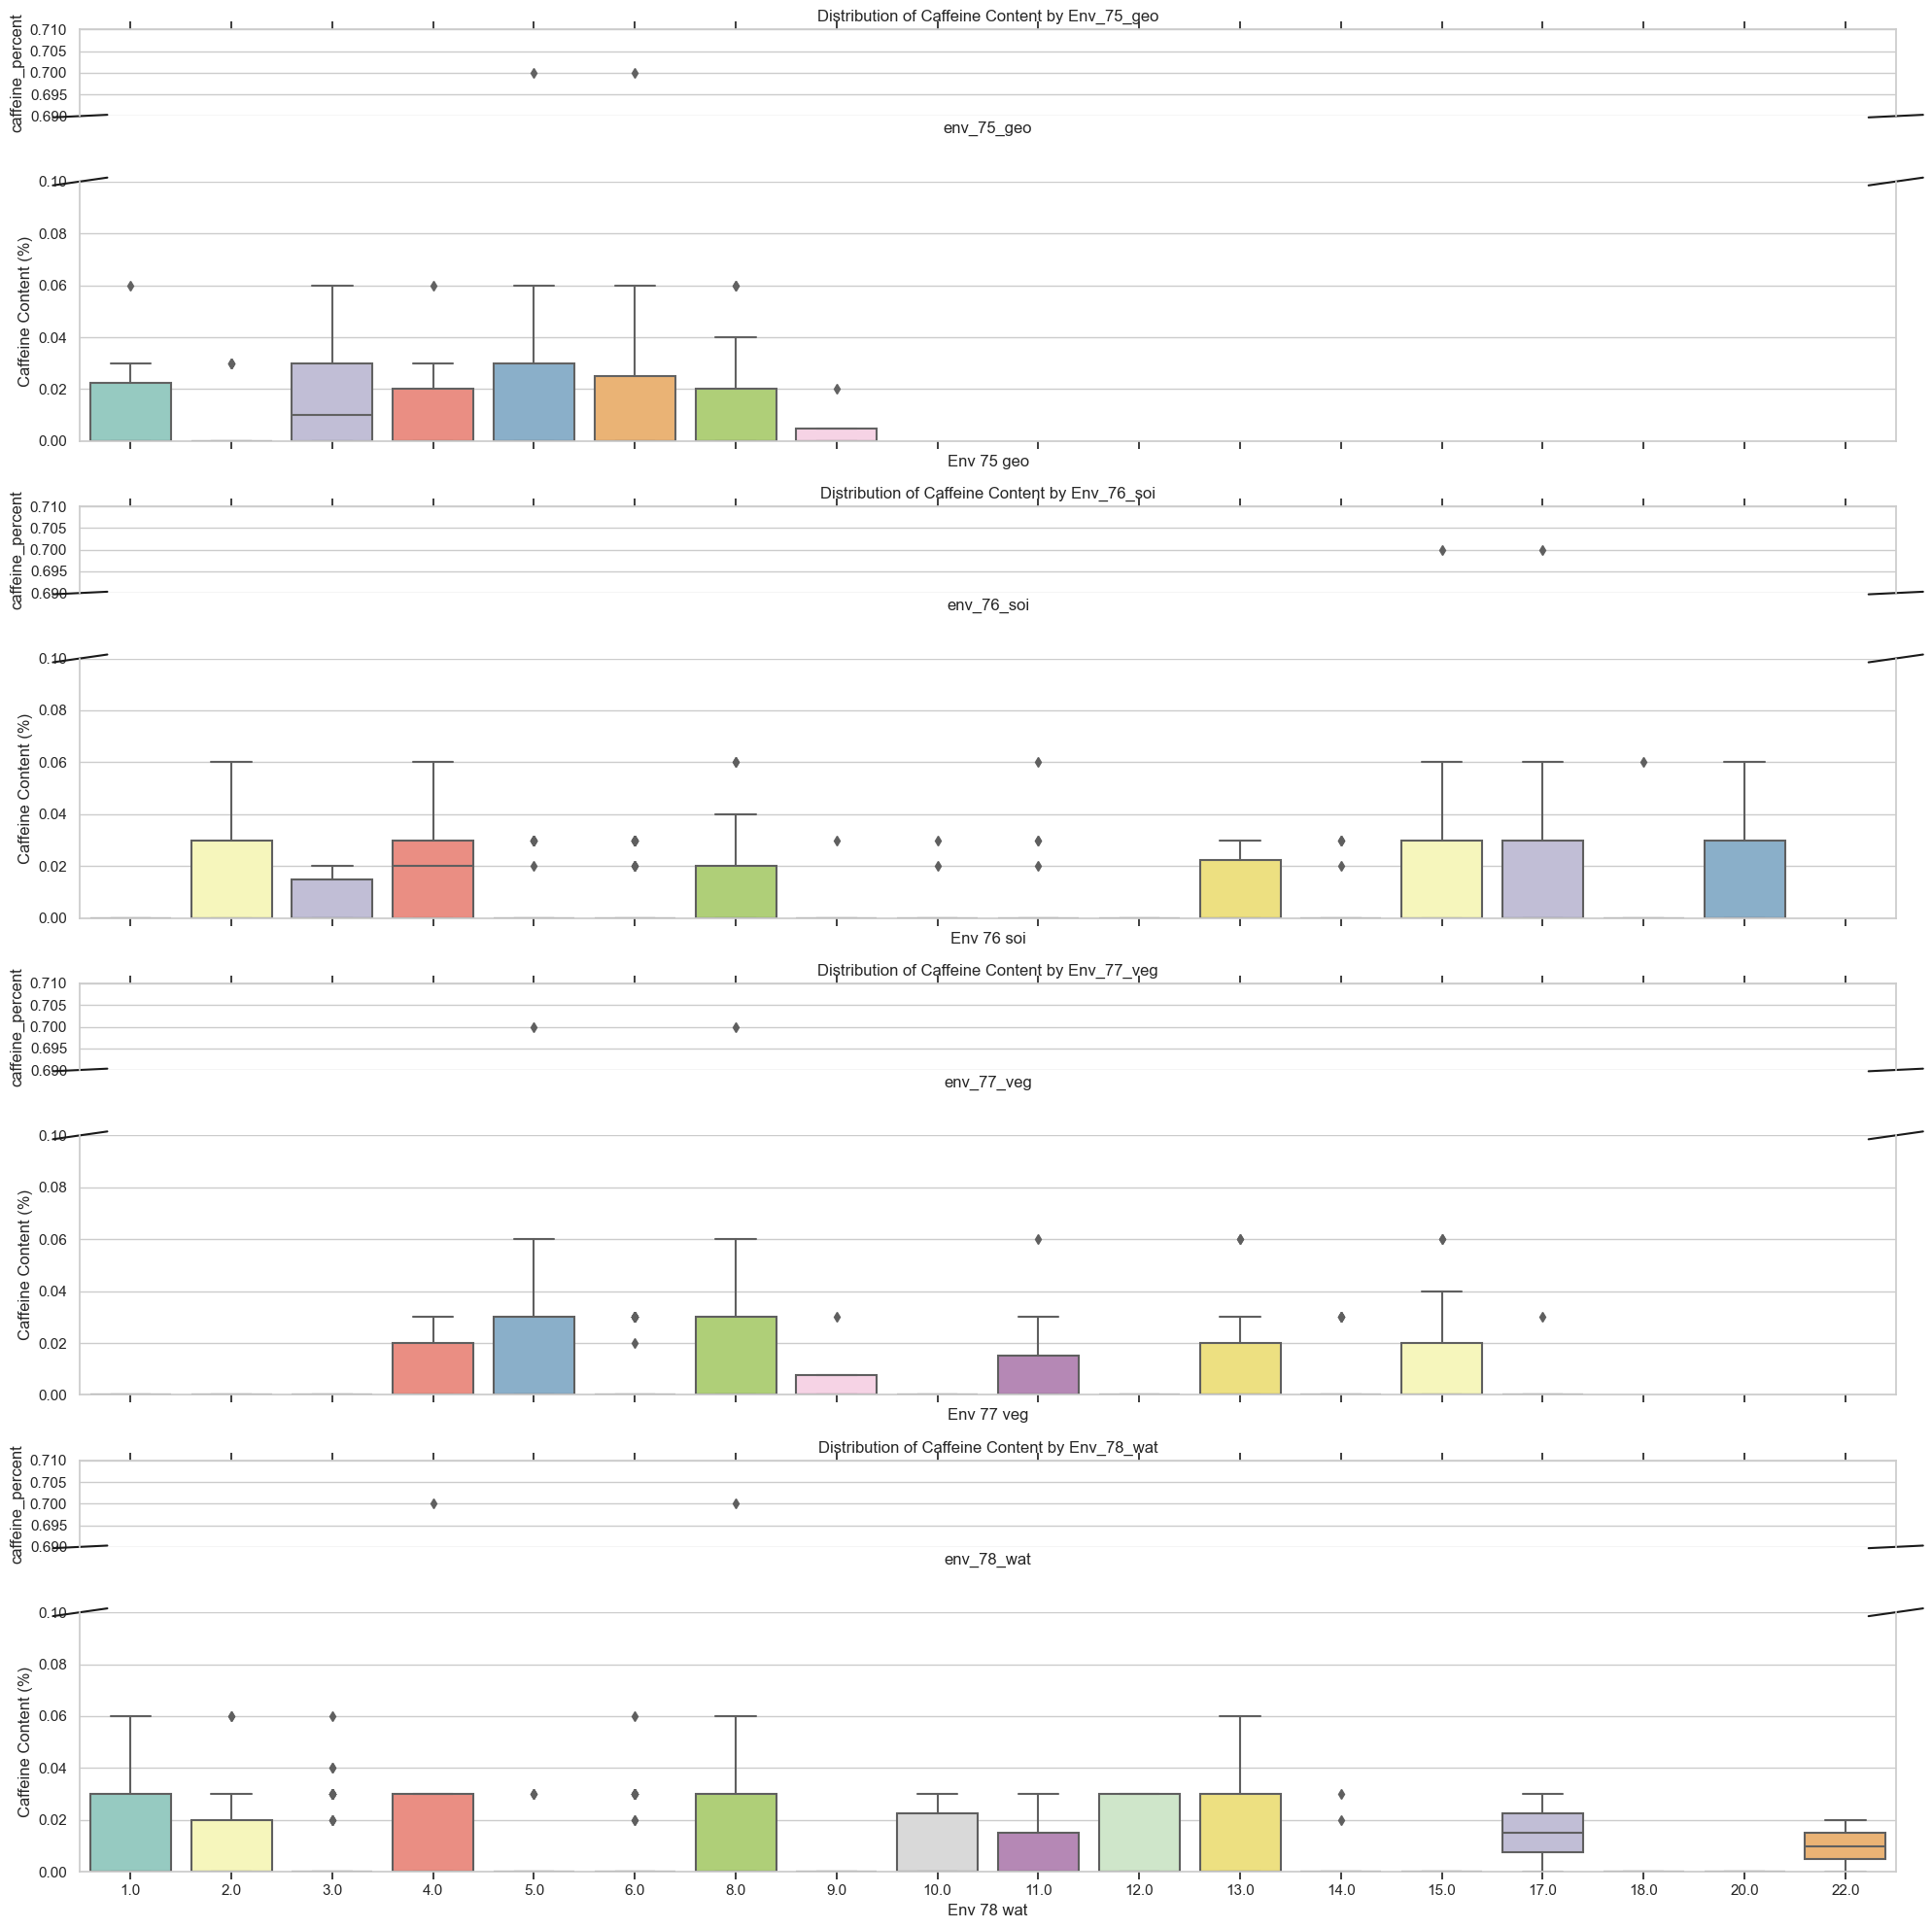

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with subplots for each categorical variable (2 subplots per variable)
fig, axes = plt.subplots(len(categorical_columns) * 2, 1, sharex=True, figsize=(20, 20),
                         gridspec_kw={'height_ratios': [1, 3] * len(categorical_columns)})

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    ax1 = axes[i * 2]  # Top plot
    ax2 = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax1)
    ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
    ax1.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=ax2)
    ax2.set_ylim(0, 0.1)  # Emphasize the main range
    ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

    # Formatting for better visualization
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    ax2.set_xlabel(column.replace('_', ' ').capitalize())
    ax2.set_ylabel('Caffeine Content (%)')
    ax1.set_title(f'Distribution of Caffeine Content by {column.capitalize()}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


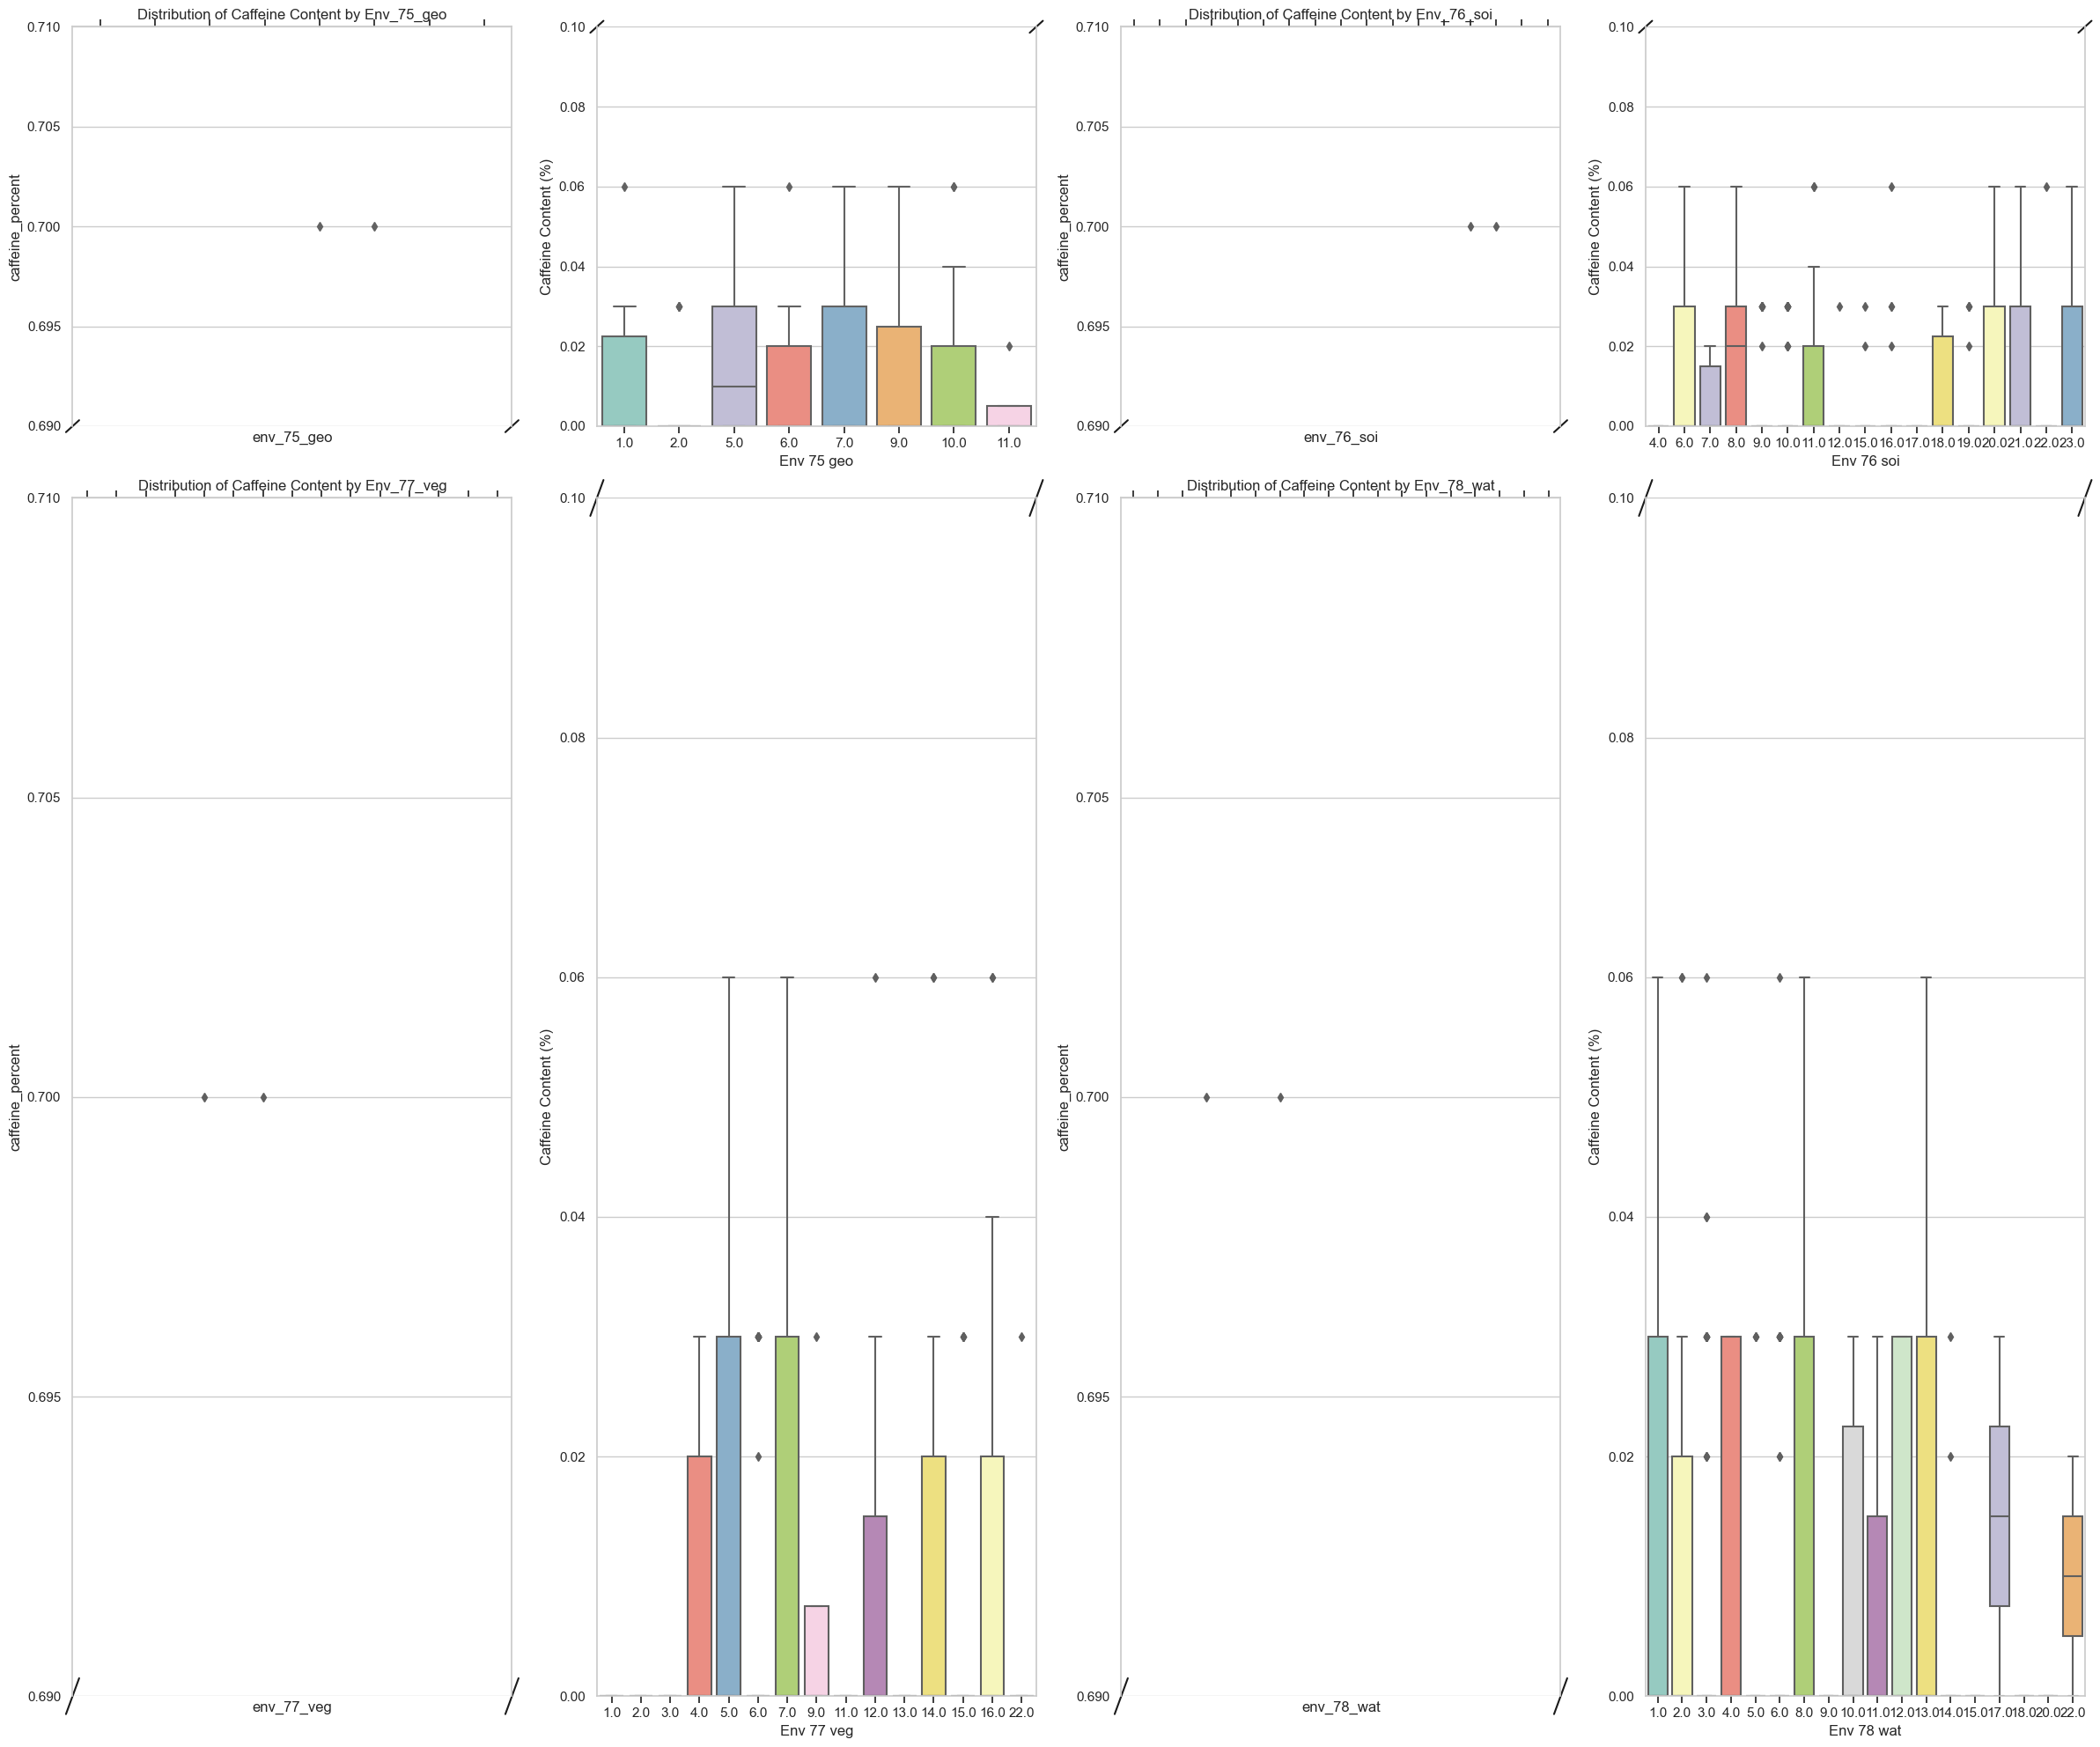

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns you want to visualize
categorical_columns = ['env_75_geo', 'env_76_soi', 'env_77_veg', 'env_78_wat']

# Create a figure with a 4x2 grid of subplots (2 rows per variable)
fig, axes = plt.subplots(2, 4, figsize=(24, 20), gridspec_kw={'height_ratios': [1, 3]})

# Flatten the axes for easier iteration
axes = axes.flatten()

# Loop through each column and create a box plot with a broken y-axis
for i, column in enumerate(categorical_columns):
    top_ax = axes[i * 2]  # Top plot
    bottom_ax = axes[i * 2 + 1]  # Bottom plot
    
    # Top plot (focused on 0.69 to 0.71 range)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=top_ax)
    top_ax.set_ylim(0.69, 0.71)  # Display a small range above the break
    top_ax.set_yticks(np.arange(0.69, 0.71, 0.005))  # Adjust interval for the narrow section
    top_ax.spines['bottom'].set_visible(False)
    top_ax.xaxis.tick_top()
    top_ax.tick_params(labeltop=False)

    # Bottom plot (below 0.1)
    sns.boxplot(x=column, y='caffeine_percent', data=df, palette='Set3', ax=bottom_ax)
    bottom_ax.set_ylim(0, 0.1)  # Emphasize the main range
    bottom_ax.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
    bottom_ax.spines['top'].set_visible(False)
    bottom_ax.xaxis.tick_bottom()

    # Add diagonal lines to indicate the break in the y-axis for top and bottom plots
    d = .015  # How big to make the diagonal lines in axes coordinates
    kwargs = dict(transform=top_ax.transAxes, color='k', clip_on=False)
    top_ax.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
    top_ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

    kwargs.update(transform=bottom_ax.transAxes)  # Switch to the bottom axes
    bottom_ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
    bottom_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    # Set labels and titles
    bottom_ax.set_xlabel(column.replace('_', ' ').capitalize())
    bottom_ax.set_ylabel('Caffeine Content (%)')
    top_ax.set_title(f'Distribution of Caffeine Content by {column.capitalize()}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


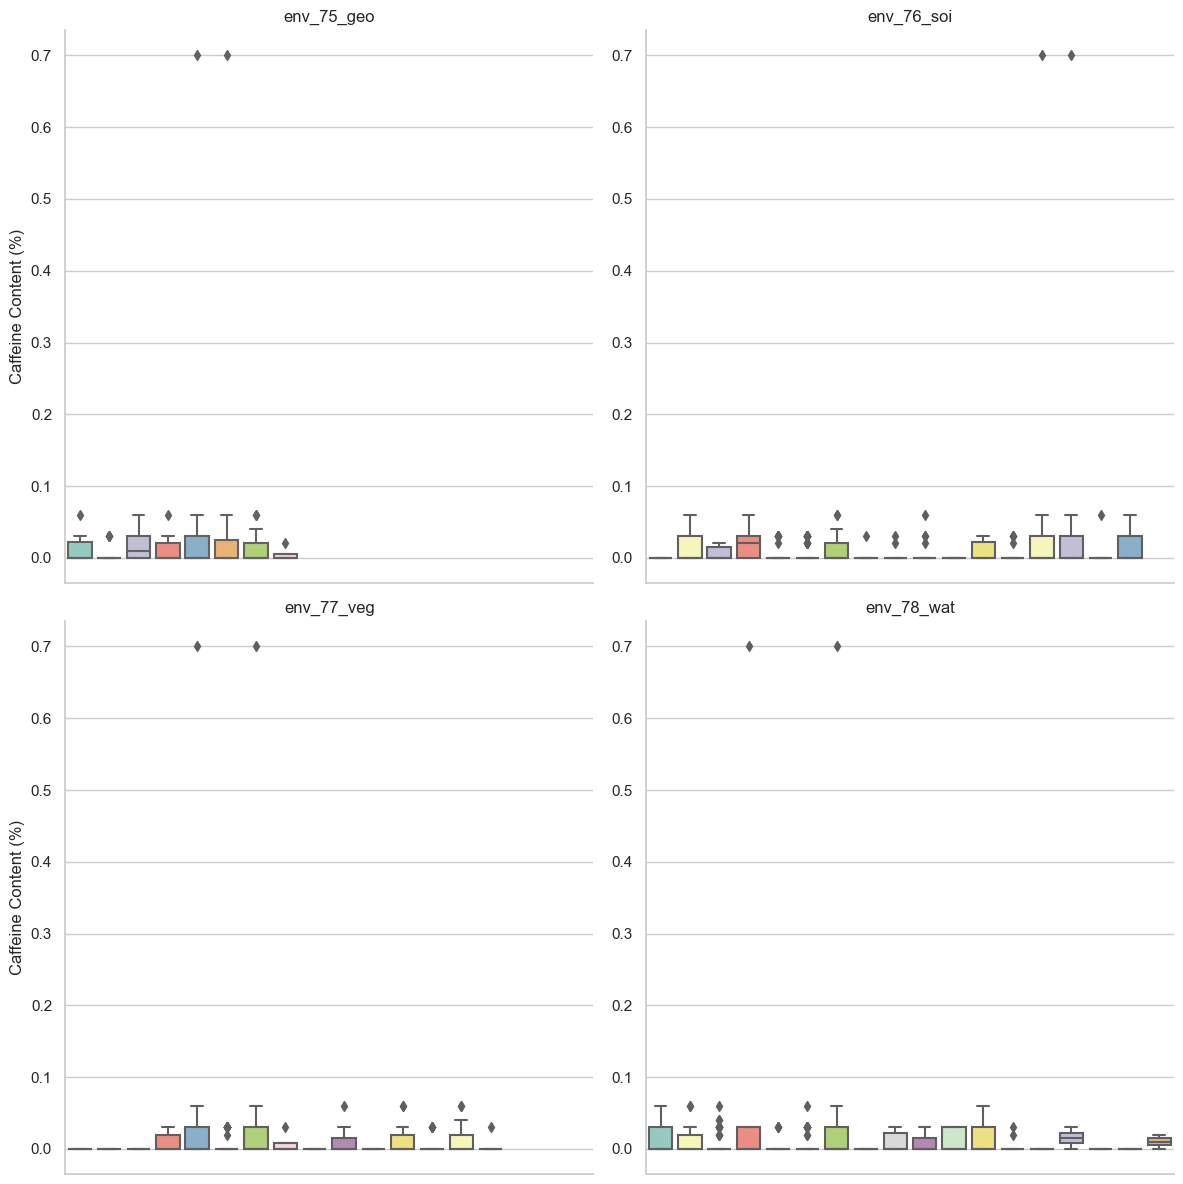

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')

# Melt the DataFrame to have a common 'Category' column for the categorical variables
melted_df = pd.melt(df, id_vars='caffeine_percent', value_vars=['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat' ],
                    var_name='Category', value_name='Category Value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='Category', col_wrap=2, height=6, sharey=False)
g.map_dataframe(sns.boxplot, x='Category Value', y='caffeine_percent', palette='Set3')

# Customize the plots
g.set_titles("{col_name}")
g.set_axis_labels("", "Caffeine Content (%)")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


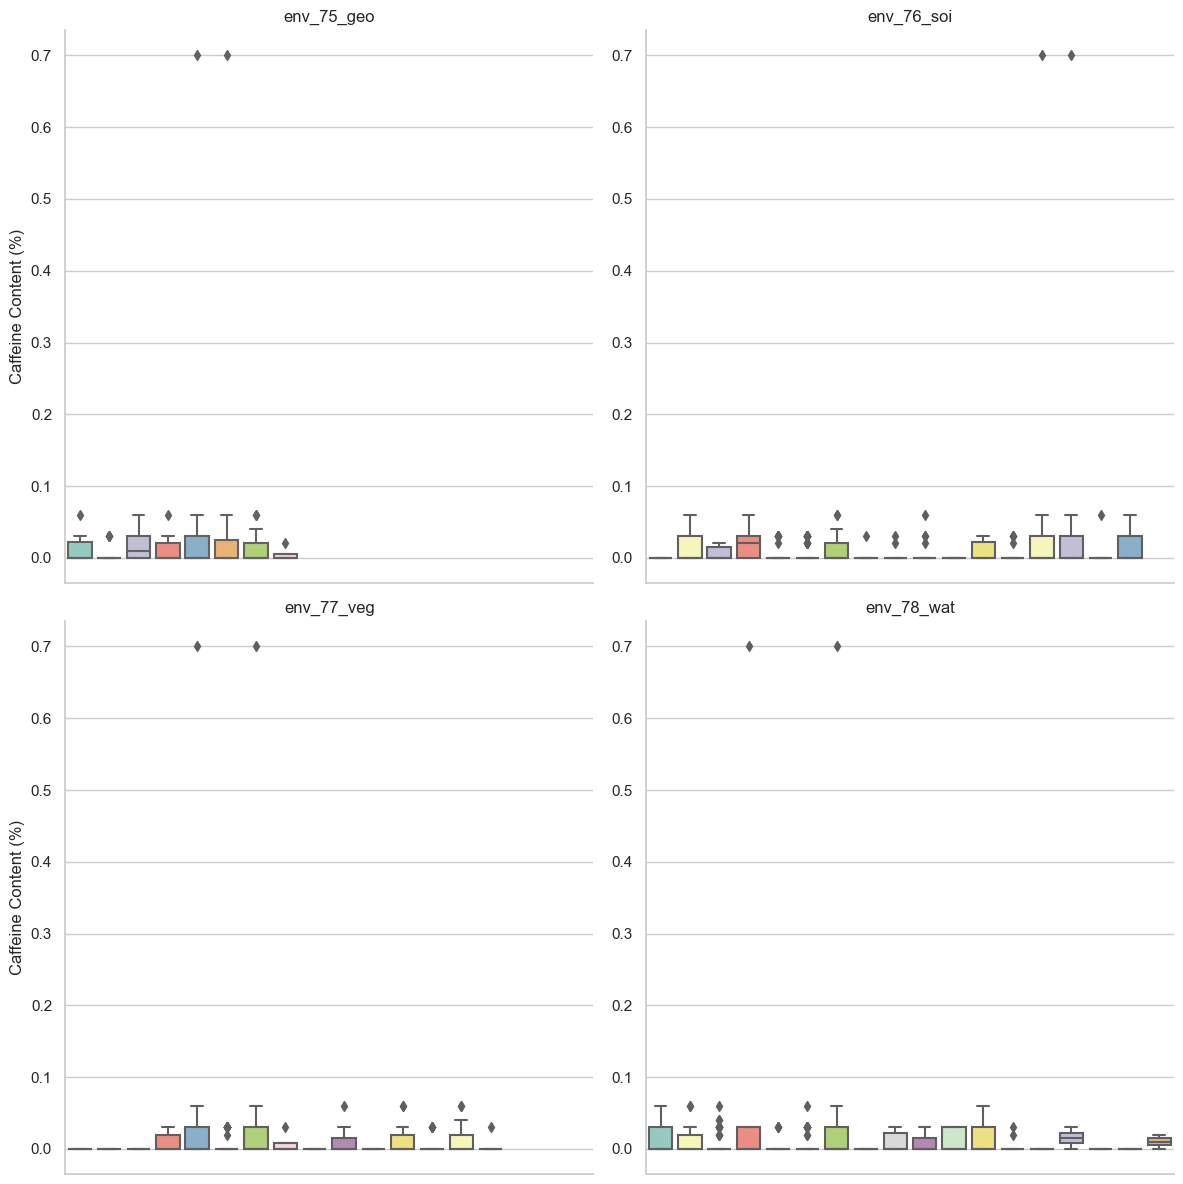

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')

# Melt the DataFrame to have a common 'Category' column for the categorical variables
melted_df = pd.melt(df, id_vars='caffeine_percent', value_vars=['env_75_geo', 'env_76_soi',  'env_77_veg',  'env_78_wat'],
                    var_name='Category', value_name='Category Value')

# Create a FacetGrid
g = sns.FacetGrid(melted_df, col='Category', col_wrap=2, height=6, sharey=False)
g.map_dataframe(sns.boxplot, x='Category Value', y='caffeine_percent', palette='Set3')

# Customize the plots
g.set_titles("{col_name}")
g.set_axis_labels("", "Caffeine Content (%)")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate and align labels

plt.tight_layout()
plt.show()


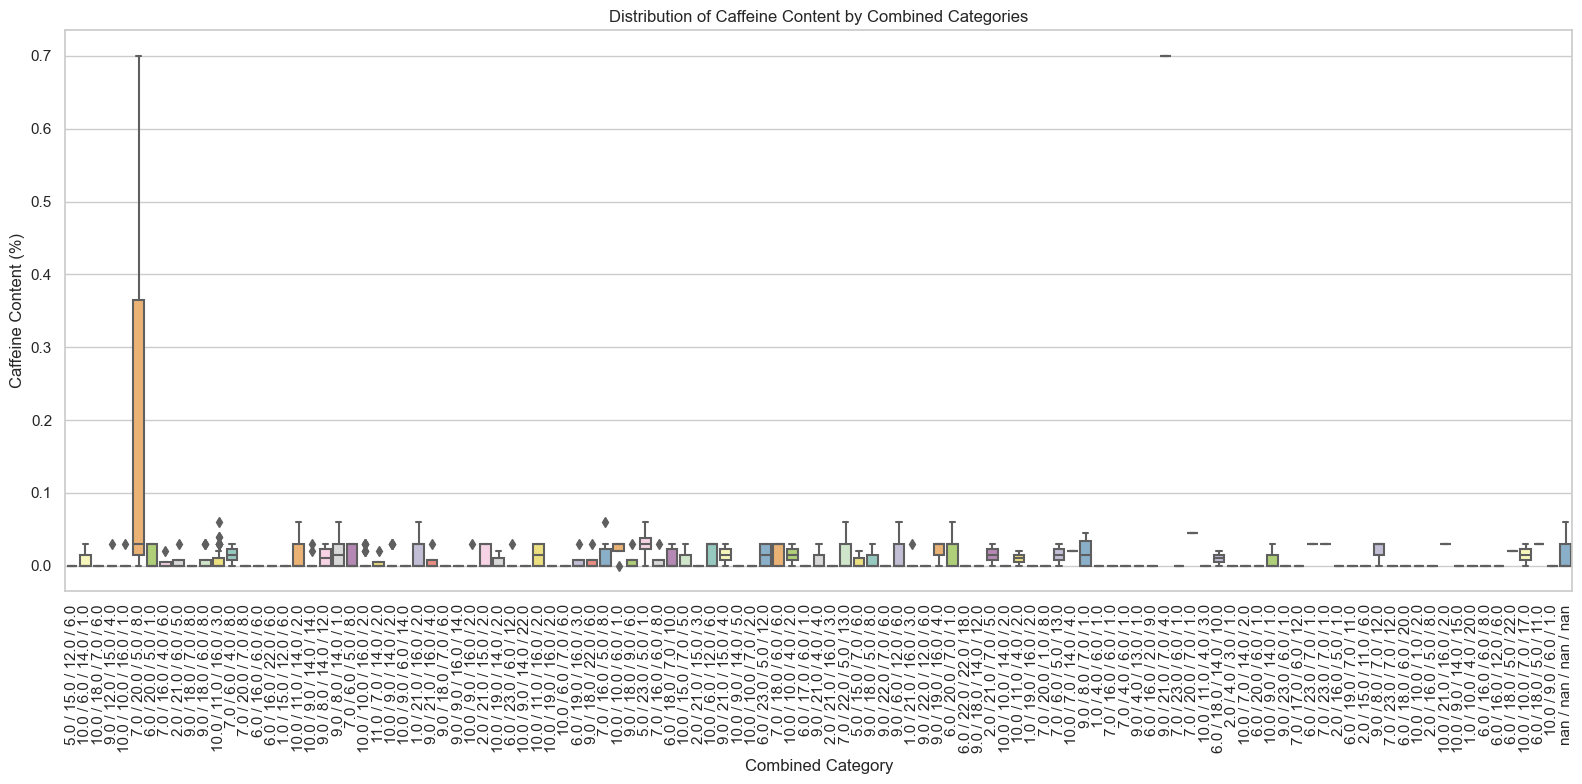

In [37]:
'', '',  '',  ''

import seaborn as sns
import matplotlib.pyplot as plt

# Combine all categories into a new column for grouping
df['combined_category'] = (df['env_75_geo'].astype(str) + " / " +
                           df['env_76_soi'].astype(str) + " / " +
                           df['env_77_veg'].astype(str) + " / " +
                           df['env_78_wat'].astype(str))

# Plot with a grouped boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(x='combined_category', y='caffeine_percent', data=df, palette='Set3')
plt.title('Distribution of Caffeine Content by Combined Categories')
plt.xlabel('Combined Category')
plt.ylabel('Caffeine Content (%)')
plt.xticks(rotation=90, ha='center')  # Rotate and center align labels
plt.tight_layout()
plt.show()
